In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, classification_report


In [14]:
import sys
print(sys.executable)

d:\ML-IA\Customer-Churn-Predictor\venv\Scripts\python.exe


In [15]:
# Load data
df = pd.read_csv("../data/Telco-Customer-Churn.csv")

# Cleaning
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

# Remove customerID
df = df.drop("customerID", axis=1)

# Encode target
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

# Split X and y
X = df.drop("Churn", axis=1)
y = df["Churn"]

# One-hot Encoding
X = pd.get_dummies(X, drop_first=True)

# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [16]:
BASE_DIR = os.path.dirname(os.getcwd()) # goes up from notebooks folder

model_path = os.path.join(BASE_DIR, "models/churn_model.pkl")
scaler_path = os.path.join(BASE_DIR, "models/scaler.pkl")

model = joblib.load(model_path)
scaler = joblib.load(scaler_path)


In [17]:
# Scaler
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

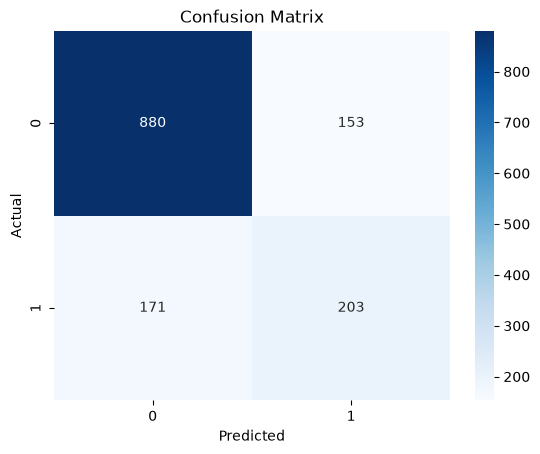

In [18]:
# confusion matrix

y_pred = model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
# Classification report

classificationReport = classification_report(y_test, y_pred)

print(classificationReport)

              precision    recall  f1-score   support

           0       0.84      0.85      0.84      1033
           1       0.57      0.54      0.56       374

    accuracy                           0.77      1407
   macro avg       0.70      0.70      0.70      1407
weighted avg       0.77      0.77      0.77      1407



In [20]:
y_prob = model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

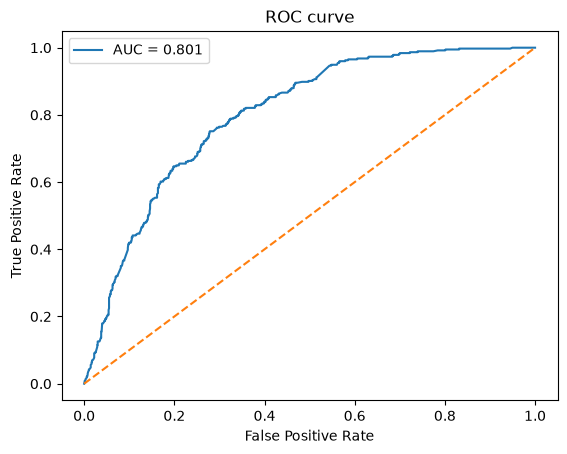

In [21]:
plt.Figure(figsize=(8,5))

plt.plot(
    fpr,
    tpr,
    label = f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve")
plt.legend()
plt.show()

In [25]:
feature_importance = pd.DataFrame({
    "Features": X.columns,
    "importance": model.feature_importances_
    }).sort_values(by="importance",ascending=False)

top_features = feature_importance.head(10)

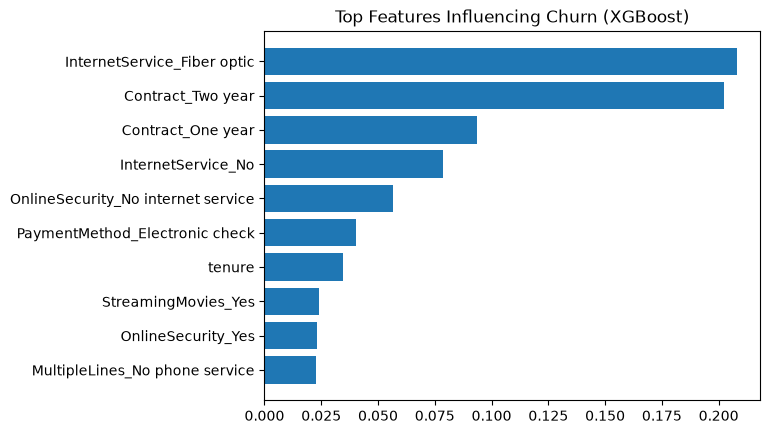

In [27]:
plt.Figure(figsize=(10,5))
plt.barh(top_features["Features"], top_features["importance"])
plt.title("Top Features Influencing Churn (XGBoost)")
plt.gca().invert_yaxis()
plt.show()